# Laboratory 2

The topic for today's laboratory is simple image classification. It's the single laboratory in which we will got back to the basics and implement things from scratch. You will learn about loss functions, evaluation metrics and experiment management.
I suggest that you don't work in notebooks for this lab, but create a python project.



## Warm-up. numpy exercise

Let's start by implementing the softmax function. This function takes as input an array of *N* arbitrary numbers and normalizes the array such that the output is a probability distribution.


\begin{equation}
softmax(x)_i = \frac{e^{x_i}}{\sum_{j = 0}^{j = N} e^{x_j}}
\end{equation}


**Have a short discussion about softmax numerical stability.** You can also check this [post](https://ogunlao.github.io/2020/04/26/you_dont_really_know_softmax.html).


In [9]:
import numpy as np
import torch

def softmax(x, T=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x / T
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

arr = np.asarray([2, 4, 10, 100, 2.0])
assert np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr))

arr = np.asarray([0.0, 0, 0, 1, 0])
assert np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr))

arr = np.asarray([-750.0, 23, 9, 10, 230])
assert np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr))

arr = np.ones((4,))
assert np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr))

arr = np.zeros((4,))
assert np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr))

print("All tests passed.")

All tests passed.


*Softmax temperature* is a concept that we'll be using later in this course.
The *softmax temperature* is a hyper-parameter (positive number) which scales the input of the softmax function to modify the output probabilities.


\begin{equation}
s(x, T)_i = \frac{e^{x_i/T}}{\sum_{j = 0}^{j = N} e^{x_j/T}}
\end{equation}

Now modify your implementation of the softmax function such that it also takes as input the softmax temperature (a positive floating point number). If this parameter is not specified, it should default to 1.


Now let's visualise what is the effect of the softmax temperature.
Given the input vector *x = [100, 2, -150, 75, 99, 3]* , plot the original vector and the softmax with temperatures $ T \in \{0.25, 0.75, 1, 1.5, 2, 5, 10, 20, 30\} $.

You can use a bar plot for this. The title for each plot should be the value of the softmax temperature. Also, make sure that for all the plots the range of the *y* axis is set to (0, 1).



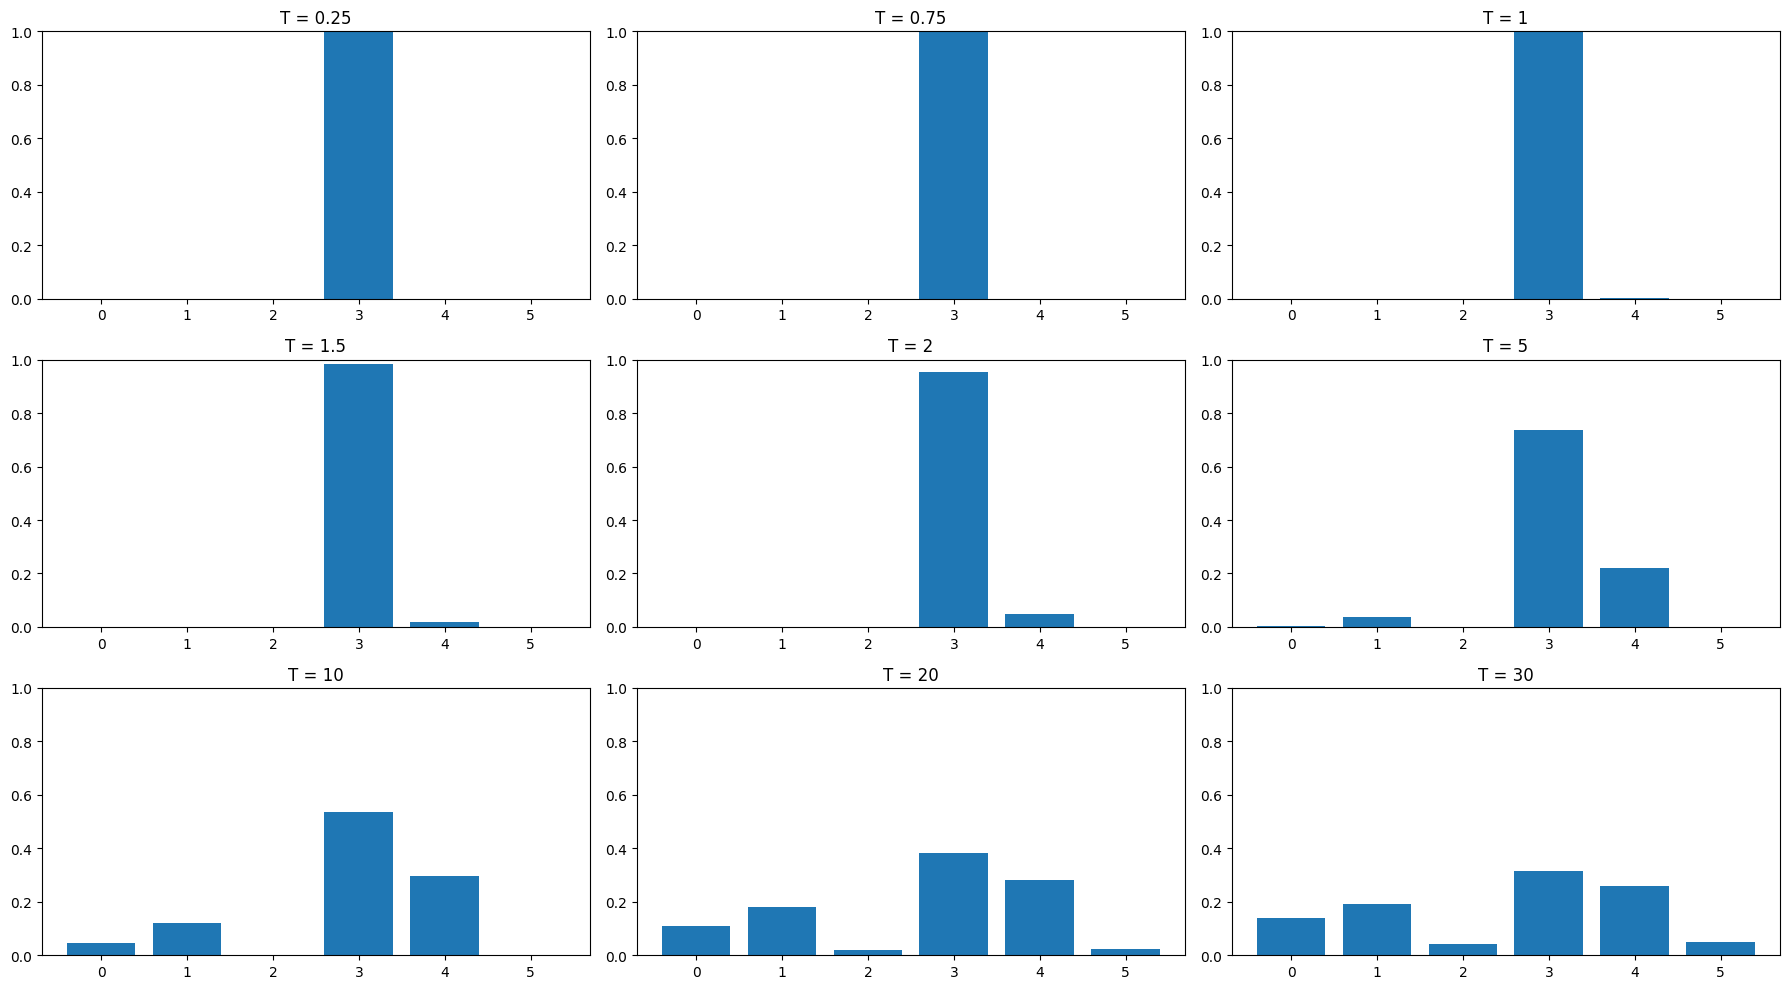

In [10]:
# your code here
import matplotlib.pyplot as plt
x = np.asarray([20, 30, -15, 45, 39, -10])
T = [0.25, 0.75, 1, 1.5, 2, 5, 10, 20, 30]

plt.figure(figsize=(18, 10))

for idx in range(0, len(T)):
  # TODO your code here
  # plot the result of applying the softmax function
  # with different temperatures on the array x

  y = softmax(x, T[idx])

  plt.subplot(3, 3, idx + 1)
  plt.bar(np.arange(len(x)), y)
  plt.ylim(0, 1)
  plt.title(f"T = {T[idx]}")
  plt.xticks(np.arange(len(x)))

  # end TODO your code here

plt.tight_layout()
plt.show()

Analyse the plots and answer the following questions:
* What happens when we use a large number for the softmax temperature?
* What happens when we use a small number (i.e. less than 1) for the softmax temperature?
* In the context of image classification, the predicted class is determined by taking the *argmax* of the softmax function. Does the softmax temperature change in any way this prediction?

1. A large softmax temperature makes the output distribution flatter and more uniform. The model becomes less confident because the probabilities are spread across more classes.

2. A small softmax temperature (T < 1) makes the output distribution sharper and more concentrated on the largest logit. The model becomes more confident.

3. No. In general, temperature does not change the predicted class because argmax depends only on the order of the logits, and dividing by a positive temperature does not change that order. It only changes the probability values, not usually the final predicted class.

## Dataset

We'll be using CIFAR-10 dataset.
The dataset comprises 60000 colour images with a resolution of $32 \times 32$, separated into 10 classes, with 6000 images per class. It is already split into train-test subsets, with 50000 training images and 10000 test images.

You can download the data from this [link](https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz).

In [11]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvf cifar-10-python.tar.gz

--2026-03-18 20:34:53--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M   955KB/s    in 3m 38s  

2026-03-18 20:38:31 (763 KB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


1.  **Write a script *cifar10.py* in which will write the function load_cifar10, which load the data from the archive you just downloaded.**

The images of this dataset are are stored in a numpy array, one image per row, in the following order:

"_The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image._"

Your task here is just to manipulate this array, such that each image has the shape (32, 32, 3) and uses RGB ordering.

In [15]:
import os
import pickle
import numpy as np

LABELS = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

def _load_batch(path):
    with open(path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    x = batch[b"data"]
    y = np.array(batch[b"labels"], dtype=np.int64)
    return x, y

def _reshape_images(x):
    x = np.asarray(x, dtype=np.uint8)
    x = x.reshape(-1, 3, 32, 32)        # (N, C, H, W)
    x = np.transpose(x, (0, 2, 3, 1))   # (N, H, W, C)
    return x

def load_cifar10(root_dir):
    x_train_list = []
    y_train_list = []

    for i in range(1, 6):
        path = os.path.join(root_dir, f"data_batch_{i}")
        x, y = _load_batch(path)
        x_train_list.append(x)
        y_train_list.append(y)

    x_train = np.concatenate(x_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)

    x_test, y_test = _load_batch(os.path.join(root_dir, "test_batch"))

    x_train = _reshape_images(x_train)
    x_test = _reshape_images(x_test)

    return x_train, y_train, x_test, y_test

2. **Using matplotlib, write a function that visualizes some of the images from the CIFAR-10 dataset.**

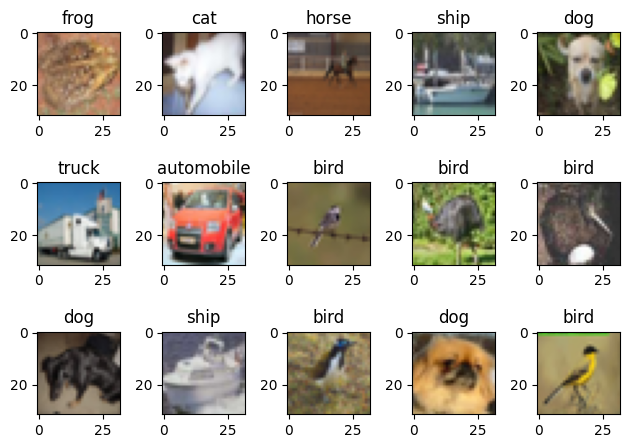

In [17]:
cifar_root_dir = 'cifar-10-batches-py'
X_train, y_train, X_test, y_test = load_cifar10(cifar_root_dir)
indices = np.random.choice(len(X_test), 15)

display_images, display_labels = X_test[indices], y_test[indices]
for idx, (img, label) in enumerate(zip(display_images, display_labels)):
    plt.subplot(3, 5, idx + 1)
    plt.imshow(img)
    plt.title(LABELS[label])
    plt.tight_layout()
plt.show()

# Image classification using a linear classifier in pytorch




Image classification refers to the problem of automatically assigning a label (a class) to an image $X_i$. As classification is a supervised learning problem, each image is assigned a ground truth label $y_i \in \{1, 2, ..., C\}$.


Today you will implement and train the simplest possible artificial neural network using pytorch.
A linear classifier uses a function $f$ to map an input image $X_i \in R^{H\times W\times 3}$ into a vector of C class scores  $\hat y_i \in R^C$:


\begin{equation}
f(X_i) = X_i \cdot W + b
\end{equation}


The learnable parameters of the classifier are the weight matrix $W$ and the bias vector $b$. Using the bias trick the bias term can be included in the weight matrix.


During the training process, the values of the weight matrix are learned by minimizing a loss function (that penalizes the discrepancy between the predicted and the ground truth label).


In your implementation, use the bias trick and add the bias value in the weight matrix and a 1 in the training and test data:


```
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
```


## Implementation


[Pytorch](https://pytorch.org/) is a powerful machine learning framework widely used for computer vision and natural language processing applications that we'll be using this semester.
[Tensors](https://pytorch.org/docs/stable/tensors.html) are the main data abstraction from pytorch; similar to numpy arrays, they represent multi-dimensional arrays of a single data type.
You can think of a tensor as consisting of some data, and then some metadata describing the size of the tensor, the type of the elements it contains (dtype) and what device the tensor lives on (CPU memory? CUDA memory?).


It is quite easy to transform tensors to and from numpy arrays:
- _from_numpy()_ function allows you to create a pytorch tensor from a numpy array.
- _numpy()_ functions allows you to convert a tensor to a numpy() array.


Also, you will use the function _item()_ to convert a tensor to a scalar python value.


Another important feature of pytorch is the _autograd_ module that provides classes and functions for automatic differentiation of arbitrary scalar valued functions. This module is really easy to use, you only need to declare Tensor's for which gradients should be computed by setting the _requires_grad_ attribute of a tensor to True.
As you know, most machine learning models are trained using the gradient descent algorithm. This is a first-order iterative optimization algorithm used to find the minimum of a differentiable function: the main idea is to take repeated steps in the opposite direction of the gradient  of the function at the current point (i.e. in the direction of steepest descent).






### Softmax classification


We'll follow an object oriented approach to solve this problem.
All the code related to the softmax classifier will be implemented in a class *SoftmaxClassifier* (defined in the script _softmax.py_).


The _SoftmaxClassifier_ class contains in the  attribute _self.W_ the weight matrix that will be learned during the training process.  


The class should have the following methods:


| Method                               | Description |
| ----------- | ----------- |
| initialize()      | This function randomly initializes the weights of the linear classifier.    |
| fit(X_train, y_train, **kwargs)      | This function will learn the weights of the model based on the training data samples (X_train) and their corresponding ground truth (y_train)       |
|  predict(X)                | This function will return the classifier's prediction (the predicted class) for the data passed as parameter.        |
|  predict_proba(X)                | This function will return the classifier's predictions for the data passed as parameters.        |
|  save(path)   | This function will dump the weights of the classifier in the path specified as parameter.        |
|  load(load)   | This function will load the classifier's weights from the path specified as parameter      |


Feel free to add any additional helper methods if needed.


#### Initialization and persistence
* The constructor of this class takes as input the flattened size of the input image and the number of output classes, sets the corresponding class variables and calls the _init()_ method.
* fill in the _initialize()_ method. You figure out the shape of the weight matrix based on the input shape and the number of classes. Initialize the weight matrix with small random variables.
__Use the bias trick__!
* fill in the _save_ and _load_ functions. In these functions you should just dump and restore, respectively, the weight matrix to/from the specified file.


#### Inference - the _predict_ and _predict\_proba_ methods


The inference is quite simple. You just need to compute the dot product between the input and the weight matrix.
You will implement two inference methods:
* _predict_ - this will just return the predicted class label. So you just need to compute the dot product and take the argmax of the result.
* _predict\_proba_ - this will return the class probabilities. So after computing the dot product, you also need to apply the softmax function on the result to normalize it to a probability distribution.


If you implement this correctly, the _SoftmaxClassifier_ can be used to make predictions, but of course they are not very accurate as we haven't trained the model yet.



#### Training - the _fit_ method

The training process is implemented in the function _fit_ : here we are interested in finding the values for the weight matrix such that the classifier gives accurate predictions.

The loss function for the softmax classifier is defined as:

\begin{equation}
L_i = - \sum_{i=1}^{C} log(\hat{y\_pred}_i)\cdot y_i.
\end{equation}

, where $\hat{y_p}_i$ are the probabilities returned by the classifier for the ith sample and $y_i$ is the corresponding ground truth (as one hot encoding).

So in the ``cross_entropy`` function you just take the negative of the logarithm of the predicted probability for the ground truth class.

In the case of the softmax classifier $\hat{y\_pred}_i$ is always a value in the interval [0, 1] (we use the softmax function to normalize the logits into a probability distribution).
When the probability of the ground truth class is small (i.e. close to 0), the loss will be very high (theoretically, infinite) [log(0) = -inf]. On the other hand, when the probability of the correct class will be high (i.e. close to 1), then the loss will be close to 0 [log(1) = 0].

For numerical staibility instead of using softmax, we'll use the log softmax.

In the function `log_softmax` implement the following:
\begin{equation}
log\_softmax(x_i) =  log(\frac{e^{x_i}}{\sum_{j}e^{x_j}}) = x_i - log(\sum_j e^x_j)
\end{equation}

Then, in the ``fit`` method:
\begin{equation}
y\_pred_i = f(x_i)
\end{equation}

\begin{equation}
\hat{y\_pred_i} =  log\_softmax(y\_pred_i)
\end{equation},

and take the cross entropy loss between $\hat{y\_pred_i}$ and $y_i$ to compute the data loss.

For this we need two steps:
1. we need to define a loss function that quantifies our
how well is the classifier doing on the training data. The loss function that we will use is the **cross entropy loss**.
Remember from the lecture that, in order to avoid overfitting, a regularization term is added to the loss function.
You will implement the $L_2$ regularization, in which you also add the  sum of squares of all of the feature weights to the loss.


2. we need an algorithm to efficiently find the
parameters that minimize the loss function.

Pytorch provides a powerful feature, _autograd_: it allows for the rapid and easy computation of multiple partial derivatives (also referred to as gradients) over a complex computation. This operation is central to backpropagation-based neural network learning.

You can follow [this](https://pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html) post for more details about how autograd works.
We'll cover autograd in more detail in the next labs.

For now, we'll be using it to make your life easier when implementing gradient descent to train the softmax classifier. In gradient descent, the idea is to take repeated steps in the opposite direction of the gradient of the loss function at the current point. The backpropagation algorithm works by computing the gradient of the loss function with respect to each weight by the chain rule, computing the gradient one layer at a time, and iterating backward from the last layer to avoid redundant calculations of intermediate terms in the chain rule.

To signal autograd that it should collect the gradients of a tensor, you need to pass the parameter _requires_grad=True_ when creating it or call the method _requires_grad_()_ on a tensor.

To __start the backpropagation__ with autograd, you just need to call the _backward()_ function on the loss tensor (a scalar).  
Autograd calculates and stores the gradients for each model parameter in the tensors' _grad_ field.

Let's see how a custom training loop looks in pytorch:

```python
lr = 0.05  # learning rate: what is the size of the step that we will take in the opposite direction of the gradient
epochs = 32  # how many epochs (passes through the traing data) we'll peform
bs = 32 # batch size:  we'll update the parameters after seeing several examples (a batch of data)

for epoch in range(epochs):    
    for ii in range((X_train.shape[0] - 1) // bs + 1):  # in batches of size bs
        start_idx = ii * bs  # we are ii batches in, each of size bs
        end_idx = start_idx + bs  # get bs examples

        # get the training training examples xb, and their coresponding annotations
        xb = X_train[start_idx:end_idx]
        yb = y_train[start_idx:end_idx]

        # apply the model on the training examples
        pred = predict_proba(xb)

        # compute the loss function
        loss = cross_entropy_loss(pred, yb)

        # start backpropagation: calculate the gradients with a backwards pass
        loss.backward()

        # update the parameters
        with torch.no_grad():  # we don't want to track gradients
            # take a step in the negative direction of the gradient, the learning rate defines the step size
            weights -= weights.grad * lr

            # ATTENTION: you need to explictly set the gradients to 0 (let pytorch know that you are done with them).
            weights.grad.zero_()
            
``





## Putting it all together


By now you have implemented all the blocks needed to train a softmax classifier. Now it is time to train the classifier using different hyperparameters.

Try different values for the hyper-parameters of the classifier (the learning rate $\lambda$ and the regularization strength $\rho$).


## Visualizing learned weights as class templates

After training the linear classifier, the weight matrix `W` has shape `(10, 3072)`,
one row per CIFAR-10 class. Since each input image is flattened into a vector,
each row of `W` can be reshaped back into an image of size $32 \times 32 \times 3$.

For a given class $c$, the classifier computes the score  
$s_c = w_c^T x + b_c$.  
This score is large when the input image $x$ is similar to the weight vector
$w_c$ in terms of correlation. During training, the model learns each `w_c` so
that images of class $c$ align well with it, while images from other classes do
not.

Because of this, each row of the weight matrix can be interpreted as a rough
**template** for its class. Visualizing these weights usually does not produce
clean images, but you can often recognize coarse structure such as dominant
colors or simple shapes. This gives an intuitive view of what a linear classifier
has learned about each class in the CIFAR-10 dataset.


## Refactoring using torch components


Luckily pytorch provides implementation for most of the layers used in modern machine learning, as well as loss functions, metrics, and optimization algorithms.


To define a model, you must extend the torch.nn.Module class which is the base class for all the neural network modules. In the constructor, you define the layers (and their properties) that comprise your module. The line


Another important function that you need to override is the forward() function in which you specify computation performed at every call (i.e. how are layers chained and how does the data flow over the computational graph). In other words, this defines the forward pass through your model.



In [18]:
import torch
from torch import nn

class Cifar10Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(32 * 32 * 3, 10)

    def forward(self, x):
        return self.linear(x)

the `nn.Linear` layer is a "child"
of the `Cifar10Classifier`,
and the weight matrix is abstracted (you don't have direct access to it).


In [19]:
model = Cifar10Classifier()
print(*list(model.children()))

Linear(in_features=3072, out_features=10, bias=True)


But you can still access the parameters of the model (the bias trick is not used in this case):

In [20]:
print(*list(model.parameters()), sep="\n")

Parameter containing:
tensor([[-0.0015,  0.0027,  0.0123,  ..., -0.0072, -0.0164,  0.0039],
        [-0.0039, -0.0118, -0.0035,  ..., -0.0033,  0.0007,  0.0011],
        [-0.0083,  0.0007,  0.0017,  ..., -0.0017,  0.0033, -0.0167],
        ...,
        [-0.0114, -0.0117, -0.0120,  ...,  0.0168,  0.0073,  0.0082],
        [ 0.0179, -0.0056,  0.0025,  ...,  0.0136,  0.0087, -0.0127],
        [-0.0018,  0.0178, -0.0066,  ...,  0.0125,  0.0023, -0.0158]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0132,  0.0028, -0.0155,  0.0177, -0.0142, -0.0112, -0.0145,  0.0180,
         0.0082,  0.0116], requires_grad=True)


Torch also provides several loss functions that you can use in the `torch.nn.functional` model. Let's drop the log_softmax and cross_entropy function that you wrote and use `torch.nn.functional.cross_entropy`[function](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html).
Pay attention: you don't need to apply the log-softmax on the prediction of the model as the function operates directly on  unnormalized logits.

In [21]:
loss_func = torch.nn.functional.cross_entropy

The optimization process (applying gradients to find the parameters and resetting those gradients to zero) can be handled more elegantly using predefined pytorch classes and operations.


You just need a subclass of the torch.optim.Optimizer, and it will automatically update the parameters of our model. In this example, we'll be using the Adam optimizer (which will be covered in detail in the lectures).


In [22]:
from torch import optim

def configure_optimizer(model: nn.Module) -> optim.Optimizer:
    return optim.Adam(model.parameters(), lr=3e-4)


Let's reload the data:

In [27]:
cifar_root_dir = 'cifar-10-batches-py'

# load cifar10 dataset
X_train, y_train, X_test, y_test = load_cifar10(cifar_root_dir)

# convert the training and test data to floating point
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape the training data such that we have one image per row
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

# pre-processing: subtract mean image
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_test -= mean_image

# convert everything to tensors
X_train, y_train, X_test, y_test = map(
    torch.tensor, (X_train, y_train, X_test, y_test)
)

X_train = X_train.float()
X_test = X_test.float()

Now, the training loop will be much simpler:

In [29]:
import tqdm
model = Cifar10Classifier()
opt = configure_optimizer(model)


print("before training:", loss_func(model(X_test), y_test), sep="\n\t")
epochs = 50
bs = 64
num_train = X_train.shape[0]

epochs = tqdm.tqdm(range(epochs), desc="Epochs")

for epoch in epochs:
    for ii in range((num_train - 1) // bs + 1):
        start_idx = ii * bs
        end_idx = start_idx + bs
        xb = X_train[start_idx:end_idx]
        yb = y_train[start_idx:end_idx]
        pred = model(xb) # call the forward function
        loss = loss_func(pred, yb) # apply the loss function

        loss.backward() # start the backpropagation and compute the gradients
        opt.step() # apply the parameter update
        opt.zero_grad() # zero out the gradients

with torch.no_grad():
    y_train_pred = model(X_train).argmax(dim=1)
    train_acc = (y_train_pred == y_train).float().mean()

    y_val_pred = model(X_test).argmax(dim=1)
    test_acc = (y_val_pred == y_test).float().mean()
print('Train acc ', train_acc.detach().numpy(), ' test acc ', test_acc.detach().numpy())

print("after training:", loss_func(model(X_test), y_test), sep="\n\t")

before training:
	tensor(56.2236, grad_fn=<NllLossBackward0>)


Epochs: 100%|███████████████████████████████████| 50/50 [00:18<00:00,  2.66it/s]

Train acc  0.32906  test acc  0.2719
after training:
	tensor(11.3520, grad_fn=<NllLossBackward0>)


## Classifier evaluation

After the training process, you want to evaluate the model on the test set, such that you can get an idea on how well your model will perform on unseen data.
Ideally the classes in the test set should be balanced (i.e. you should have the same number of samples for each one of the classes).

### Confusion matrix and classification metrics

The confusion matrix can be considered the foundation stone for evaluating a classifier. As the name states, it's a simple way of visualising whether/how the model is confusing the classes.

Each row of the confusion matrix represents the instances of the ground truth class, while each column represents the instances of the predicted class.

<img src="https://2.bp.blogspot.com/-EvSXDotTOwc/XMfeOGZ-CVI/AAAAAAAAEiE/oePFfvhfOQM11dgRn9FkPxlegCXbgOF4QCLcBGAs/s1600/confusionMatrxiUpdated.jpg"/>

Based on the confusion matrix, you can compute different classification metrics:
* *accuracy*: this is simply the ratio between the correctly classified samples (either positive or negative) and the total number of samples;
* _precisi**on**_ : this metric measures the ability of the classifier to capture **only** relevant samples;
* _rec**all**_ : this metric measures the ability of the classifier to spot **all** positive samples.

As you may have noticed, it is not possible to maximize precision and recall at the same time, as one comes at the cost of another.
Therefore, the $F_1$ score -- the harmonic mean between precision and recall -- was defined to combine these two metrics into a single numerical value.

\begin{equation}
F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}
\end{equation}

Write the code for computing the accuracy, precision, recall and f1-score of your classifier.

One challenge when implementing these metrics is that you are not allowed to use any repetitive loops (only numpy vectorization).

Of course, pytorch provides functions for all these metrics, but for didactical puropose and to gain a deeper understanding of nd-arrays and tenors you should implement them from scratch.



Compute the metrics on the best classifier you obtained so far.

In [30]:
with torch.no_grad():
    y_pred = model(X_test).argmax(dim=1)

# convert to numpy
y_true = y_test.cpu().numpy()
y_pred = y_pred.cpu().numpy()

num_classes = 10

# confusion matrix without loops
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
np.add.at(cm, (y_true, y_pred), 1)

# accuracy
accuracy = np.trace(cm) / np.sum(cm)

# precision, recall, f1 per class
tp = np.diag(cm).astype(np.float64)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp

precision = tp / np.maximum(tp + fp, 1e-12)
recall = tp / np.maximum(tp + fn, 1e-12)
f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

# macro averages
precision_macro = precision.mean()
recall_macro = recall.mean()
f1_macro = f1.mean()

print("Accuracy      :", accuracy)
print("Precision avg :", precision_macro)
print("Recall avg    :", recall_macro)
print("F1-score avg  :", f1_macro)

Accuracy      : 0.2719
Precision avg : 0.2750073475105544
Recall avg    : 0.2719
F1-score avg  : 0.27008387656852023


In [31]:
for i, name in enumerate(LABELS):
    print(
        f"{name:10s} | precision={precision[i]:.4f} "
        f"recall={recall[i]:.4f} f1={f1[i]:.4f}"
    )

airplane   | precision=0.3248 recall=0.3060 f1=0.3151
automobile | precision=0.3161 recall=0.3170 f1=0.3165
bird       | precision=0.2265 recall=0.1350 f1=0.1692
cat        | precision=0.2120 recall=0.1910 f1=0.2009
deer       | precision=0.2173 recall=0.2210 f1=0.2191
dog        | precision=0.2090 recall=0.2080 f1=0.2085
frog       | precision=0.3208 recall=0.4090 f1=0.3596
horse      | precision=0.2001 recall=0.3110 f1=0.2435
ship       | precision=0.3580 recall=0.3100 f1=0.3323
truck      | precision=0.3655 recall=0.3110 f1=0.3360


## Experiment management and reproducibility

When training deep learning models, it is very easy to run *many* experiments:
changing the learning rate, the model architecture, the regularization strength,
the data preprocessing, or even just the random seed. After a few runs, it becomes
hard to answer simple questions such as:

- Which experiment performed best?
- What hyperparameters were used for that run?
- Did the model improve on the training set but not on the test set?

Experiment management is the practice of systematically **recording what you did
and what happened**, so that experiments can be compared in a meaningful way.
We will do this a lot this semester.

## Train logs vs test logs

During training, you will usually track two different kinds of quantities:

- **Training logs**: computed on the training set while the model is being optimized.
  Typical examples are training loss, training accuracy and so on.

- **Test (or validation) logs**: computed on a separate dataset *without* updating
  the model parameters. Typical examples are test loss, test accuracy and so on.

These two sets of logs serve **different purposes**:
- Training metrics tell us whether the optimization is working.
- Test metrics tell us how well the model generalizes to unseen data.

A common situation is: training loss keeps decreasing, training accuracy keeps increasing, test accuracy stops improving or starts decreasing.

This behavior is a strong indicator of **overfitting**.



## Why logging matters

If metrics are only printed to the terminal, they are easy to lose, hard to compare across runs, impossible to visualize after training has finished.

By logging losses and metrics over time, we can:
- visualize learning curves,
- compare multiple experiments side by side,
- understand the effect of hyperparameters and model choices.

To achieve this we'll use wandb.

## Weights & Biases (wandb)

Weights & Biases (wandb) is a tool that helps with experiment management.
At a minimum, it allows you to group metrics by experiment (called a *run*), log training and test metrics over time, attach hyperparameters to each run.

A typical usage pattern is:
1. Initialize a run and specify the experiment configuration (learning rate, model, etc.).
2. Log **training metrics** during optimization (e.g. `train/loss`, `train/accuracy`).
3. Log **test metrics** during evaluation (e.g. `test/loss`, `test/accuracy`).

By consistently naming metrics (for example using prefixes like `train/` and `test/`),
wandb automatically organizes them into clear and comparable plots.



## Putting it all together: experiment management in practice

Let’s now put everything we learned into action.

In this section, you will use **experiment management** to systematically explore
design choices for a simple image classification model. The goal is not only to
train a model, but to **compare experiments in a structured and reproducible way**.

You will use the **PyTorch version of the linear classifier** introduced earlier.


### Part 1 - Hyperparameter exploration

Train the linear classifier using **at least three variants** of:

- learning rate
- weight decay (L2 regularization)

For each experiment log **training loss** and **training accuracy**
- log **test loss** and **test accuracy**, store the hyperparameters in the experiment configuration



### Part 2 - Comparing loss functions


In this part, you will study how the choice of loss function affects training
and performance in a classification problem.

Train the same linear classifier multiple times, changing **only the loss
function**, while keeping the rest of the setup (model, optimizer, data split)
as consistent as possible.

- First, use **RMSE (root mean squared error)** as the training loss. This loss is
commonly used for regression, not for classification. Even though it is not
appropriate in practice, train the model anyway and observe the training
dynamics and final accuracy. Think about how RMSE treats class predictions and
why this leads to poor behavior for multiclass classification.

- Next, train the model using **cross-entropy loss**. This is the standard loss for
multiclass classification and serves as the reference point for your
experiments. Compare its convergence speed, stability, and final test accuracy
with the RMSE-based model.

- Finally, train the model using **hinge loss**, a margin-based loss that is often associated with linear classifiers. You should implement the loss function yourself. For a single training example with score vector $$s \in \mathbb{R}^C$$ and ground truth label \(y\), the multiclass hinge loss is defined as:
 $$
\mathcal{L}_{\text{hinge}}(s, y) = \sum_{j \ne y} \max\left(0,\; s_j - s_y + \Delta \right)
$$ , where: $s_y$ is the score of the correct class, $s_j$ is the score of an incorrect class, $\Delta > 0$ is a margin hyperparameter (typically $\Delta = 1$). The loss encourages the score of the correct class to be larger than the scores
of all other classes by at least the margin $\Delta$.



### Part 3 - Label smoothing

Label smoothing is a regularization technique for classification.

Instead of training with *hard* one-hot labels, we slightly soften the target
distribution. For a classification problem with \(C\) classes and smoothing
parameter $\varepsilon$, the correct class is assigned probability \(1 - \epsilon\) and the remaining probability $\varepsilon$ is distributed uniformly over  the other classes

For example, with \(C = 10\) and $\varepsilon = 0.1$ the correct class will have a probability of $0.9$ and each incorrect class will have a probability of $0.1/9$.

Label smoothing discourages over-confident predictions and it acts as a form of regularization so it can improve generalization.

Your task is to implement label smoothing **yourself** (do not use a built-in helper) retrain the linear classifier with cross-entropy + label smoothing compare the results with standard cross-entropy.



### Part 4 - Analysis and comparison
Use wandb to track all experiments. Each run should clearly record the loss
function being used, together with the learning rate and weight decay. Log
training and test loss and accuracy throughout training so that they can be
visualized over time.

After running all experiments, create a table in wandb that summarizes the
results. The table should include the loss function, learning rate, weight
decay, final training accuracy, and final test accuracy for each run. Use this
table and the logged curves to comment on how the different losses behave and
which ones are most suitable for this task.

The goal of this exercise is not to find the “best” number,
but to practice **systematic experimentation and analysis**.


In [33]:
!pip install wandb -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import wandb

In [35]:
class Cifar10Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(32 * 32 * 3, 10)

    def forward(self, x):
        return self.linear(x)

In [36]:
class RMSELoss(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, logits, targets):
        target_one_hot = F.one_hot(targets, num_classes=self.num_classes).float()
        probs = F.softmax(logits, dim=1)
        mse = ((probs - target_one_hot) ** 2).mean()
        return torch.sqrt(mse + 1e-8)

In [37]:
class MulticlassHingeLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, logits, targets):
        correct_scores = logits[torch.arange(logits.size(0)), targets].unsqueeze(1)
        margins = logits - correct_scores + self.margin
        margins[torch.arange(logits.size(0)), targets] = 0.0
        loss = torch.clamp(margins, min=0.0).sum(dim=1).mean()
        return loss

In [38]:
class CrossEntropyLabelSmoothing(nn.Module):
    def __init__(self, num_classes=10, epsilon=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.epsilon = epsilon

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)

        with torch.no_grad():
            target_dist = torch.full_like(log_probs, self.epsilon / (self.num_classes - 1))
            target_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.epsilon)

        loss = -(target_dist * log_probs).sum(dim=1).mean()
        return loss

In [39]:
def compute_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

In [40]:
def evaluate(model, X, y, loss_fn, batch_size=512):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            end = start + batch_size
            xb = X[start:end]
            yb = y[start:end]

            logits = model(xb)
            loss = loss_fn(logits, yb)

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_samples += xb.size(0)

    return {
        "loss": total_loss / total_samples,
        "acc": total_correct / total_samples,
    }

In [41]:
def train_one_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    config,
    project_name="cvdl-lab2-cifar10"
):
    wandb.init(project=project_name, config=config, reinit=True)
    cfg = wandb.config

    model = Cifar10Classifier()

    if cfg.loss_name == "cross_entropy":
        loss_fn = nn.CrossEntropyLoss()
    elif cfg.loss_name == "rmse":
        loss_fn = RMSELoss(num_classes=10)
    elif cfg.loss_name == "hinge":
        loss_fn = MulticlassHingeLoss(margin=cfg.margin)
    elif cfg.loss_name == "cross_entropy_label_smoothing":
        loss_fn = CrossEntropyLabelSmoothing(num_classes=10, epsilon=cfg.epsilon)
    else:
        raise ValueError(f"Unknown loss_name: {cfg.loss_name}")

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    batch_size = cfg.batch_size
    num_train = X_train.shape[0]

    history = []

    for epoch in tqdm.tqdm(range(cfg.epochs), desc=f"{cfg.loss_name} | lr={cfg.lr} wd={cfg.weight_decay}"):
        model.train()

        perm = torch.randperm(num_train)
        X_train_epoch = X_train[perm]
        y_train_epoch = y_train[perm]

        for start in range(0, num_train, batch_size):
            end = start + batch_size
            xb = X_train_epoch[start:end]
            yb = y_train_epoch[start:end]

            logits = model(xb)
            loss = loss_fn(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_metrics = evaluate(model, X_train, y_train, loss_fn)
        test_metrics = evaluate(model, X_test, y_test, loss_fn)

        row = {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "test_loss": test_metrics["loss"],
            "test_acc": test_metrics["acc"],
        }
        history.append(row)
        wandb.log(row)

    final_train = history[-1]["train_acc"]
    final_test = history[-1]["test_acc"]

    summary = {
        "loss_function": cfg.loss_name,
        "lr": cfg.lr,
        "weight_decay": cfg.weight_decay,
        "final_train_acc": final_train,
        "final_test_acc": final_test,
    }

    if "epsilon" in cfg:
        summary["epsilon"] = cfg.epsilon
    if "margin" in cfg:
        summary["margin"] = cfg.margin

    wandb.summary.update(summary)
    wandb.finish()

    return summary, history

In [42]:
base_config = {
    "epochs": 20,
    "batch_size": 128,
    "lr": 0.1,
    "weight_decay": 0.0,
    "loss_name": "cross_entropy",
    "margin": 1.0,
    "epsilon": 0.1,
}

In [44]:
experiment_summaries = []

In [45]:
lrs = [0.001, 0.01, 0.1]
weight_decays = [0.0, 1e-4, 1e-3]

for lr in lrs:
    for wd in weight_decays:
        cfg = dict(base_config)
        cfg["loss_name"] = "cross_entropy"
        cfg["lr"] = lr
        cfg["weight_decay"] = wd

        summary, _ = train_one_experiment(X_train, y_train, X_test, y_test, cfg)
        experiment_summaries.append(summary)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/lateral/.netrc
wandb: Currently logged in as: boros-patri (boros-patri-babes-bolyai-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▄▄▃▄▆█▆▄▃▇▄▅▃▅▇▁▁▄▅▅
test_loss,▃▄▃▄▂▁▂▅▂▁▃▁▄▃▃█▆▂▄▃
train_acc,▃▃▃▃▆█▆▄▃▇▄▆▄▅▇▁▂▅▅▅
train_loss,▃▄▃▄▂▁▂▆▂▁▃▁▄▃▃█▆▂▄▃
epoch,20
epsilon,0.1
final_test_acc,0.265
final_train_acc,0.2984
loss_function,cross_entropy
lr,0.1


cross_entropy | lr=0.1 wd=0.0001: 100%|█████████| 20/20 [00:06<00:00,  3.08it/s]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▃▅▃▅▆▃▆▄▆▁▄▅▆▆▄▄▅▅▅█
test_loss,▆▃█▃▂█▂▄▂▇▃▂▄▂▄▄▃▃▃▁
train_acc,▁▄▂▅▅▃▅▄▆▁▄▆▅▆▄▄▅▅▄█
train_loss,▆▃█▃▂█▂▄▂▇▃▂▄▂▃▄▂▃▃▁
epoch,20
epsilon,0.1
final_test_acc,0.3269
final_train_acc,0.36454
loss_function,cross_entropy
lr,0.1


cross_entropy | lr=0.1 wd=0.001: 100%|██████████| 20/20 [00:06<00:00,  3.15it/s]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▇▁█▆▆▁▄▄▅▅▃▅▃▁▃▇▇▃▄▆
test_loss,▃▄▁▂▄▂▃▃▂▁▃▁▅█▃▁▂▄▂▁
train_acc,▅▁█▅▅▂▄▄▅▆▃▇▃▁▄█▇▃▆▆
train_loss,▃▄▂▂▄▃▃▃▃▁▃▁▅█▃▁▂▄▂▁
epoch,20
epsilon,0.1
final_test_acc,0.2827
final_train_acc,0.31092
loss_function,cross_entropy
lr,0.1


In [46]:
loss_experiments = [
    {"loss_name": "rmse", "lr": 0.1, "weight_decay": 1e-4},
    {"loss_name": "cross_entropy", "lr": 0.1, "weight_decay": 1e-4},
    {"loss_name": "hinge", "lr": 0.1, "weight_decay": 1e-4, "margin": 1.0},
]

for exp in loss_experiments:
    cfg = dict(base_config)
    cfg.update(exp)

    summary, _ = train_one_experiment(X_train, y_train, X_test, y_test, cfg)
    experiment_summaries.append(summary)

rmse | lr=0.1 wd=0.0001: 100%|██████████████████| 20/20 [00:08<00:00,  2.29it/s]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▁▄▄▄▅▅▅▆▆▆▇▇▇▇█▇████
test_loss,█▅▅▅▄▄▄▃▃▃▂▂▂▂▁▂▁▁▁▁
train_acc,▁▄▅▅▅▅▅▅▆▆▇▇█▇█▇████
train_loss,█▅▄▄▄▄▄▄▃▃▂▂▁▂▁▂▁▁▁▁
epoch,20
epsilon,0.1
final_test_acc,0.2287
final_train_acc,0.22816
loss_function,rmse
lr,0.1


cross_entropy | lr=0.1 wd=0.0001: 100%|█████████| 20/20 [00:06<00:00,  3.16it/s]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▅▆▅█▄▄▃▅▇▁▅▇▆▃▆▄▄█▇▃
test_loss,▂▃▆▁▅▄█▄▃▄▄▁▄█▃▄▅▂▂▃
train_acc,▄▅▃▇▃▄▃▄▆▁▅▇▆▂▆▄▄█▇▄
train_loss,▂▄▇▂▅▄█▄▃▄▄▁▄█▃▄▅▂▂▃
epoch,20
epsilon,0.1
final_test_acc,0.2396
final_train_acc,0.27516
loss_function,cross_entropy
lr,0.1


hinge | lr=0.1 wd=0.0001: 100%|█████████████████| 20/20 [00:08<00:00,  2.28it/s]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▇▅▆▄▄█▅▄▇▅▂▅▁▅▅▅▅▅▅▄
test_loss,▁▂▂▄▃▁▄▄▁▄█▃█▄▅▄▇▄▂▄
train_acc,▆▅▆▃▄█▅▄█▅▁▆▁▅▆▅▅▅▆▄
train_loss,▂▃▃▅▃▂▄▅▁▅█▃█▄▅▄▆▄▁▄
epoch,20
epsilon,0.1
final_test_acc,0.2491
final_train_acc,0.2765
loss_function,hinge
lr,0.1


In [47]:
label_smoothing_experiments = [
    {"loss_name": "cross_entropy", "lr": 0.1, "weight_decay": 1e-4},
    {"loss_name": "cross_entropy_label_smoothing", "lr": 0.1, "weight_decay": 1e-4, "epsilon": 0.1},
]

for exp in label_smoothing_experiments:
    cfg = dict(base_config)
    cfg.update(exp)

    summary, _ = train_one_experiment(X_train, y_train, X_test, y_test, cfg)
    experiment_summaries.append(summary)

cross_entropy | lr=0.1 wd=0.0001: 100%|█████████| 20/20 [00:06<00:00,  3.20it/s]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▃▄▇▆▅▅██▅▆▆▁▆▆▆▇▆▅▂▆
test_loss,▄▂▂▄▃▄▃▂▃▃▇█▅▄▄▁▅▃█▂
train_acc,▂▃▇▅▅▅▇▇▅▆▄▁▆▅▆█▆▅▂▇
train_loss,▄▂▂▄▃▄▃▃▃▃██▅▄▄▁▅▃█▂
epoch,20
epsilon,0.1
final_test_acc,0.2891
final_train_acc,0.32218
loss_function,cross_entropy
lr,0.1


cross_entropy_label_smoothing | lr=0.1 wd=0.0001: 100%|█| 20/20 [00:05<00:00,  3


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▇▃▇▆█▆▆▁▄▅▅▆█▇▄▇▅▇▄▁
test_loss,▄▃▄▄▁▄▃▇█▅▄▁▄▃▄▃▅▁▃█
train_acc,▆▄▆▅█▆▆▁▄▆▅▇██▅▇▅▇▅▂
train_loss,▄▃▄▄▁▄▂▇█▅▃▁▄▃▄▃▄▁▃▇
epoch,20
epsilon,0.1
final_test_acc,0.1947
final_train_acc,0.21054
loss_function,cross_entropy_label_...
lr,0.1


In [48]:
table = wandb.Table(columns=[
    "loss_function",
    "lr",
    "weight_decay",
    "final_train_acc",
    "final_test_acc",
    "epsilon",
    "margin",
])

for row in experiment_summaries:
    table.add_data(
        row.get("loss_function"),
        row.get("lr"),
        row.get("weight_decay"),
        row.get("final_train_acc"),
        row.get("final_test_acc"),
        row.get("epsilon", None),
        row.get("margin", None),
    )

run = wandb.init(project="cvdl-lab2-cifar10", name="summary-table", reinit=True)
wandb.log({"experiment_summary_table": table})
wandb.finish()

## Part 1 – Hyperparameter exploration

The experiments show that both the learning rate and weight decay have a significant impact on training dynamics and final performance.

A higher learning rate leads to faster convergence, but if it is too large, training becomes unstable and the loss may oscillate. A very small learning rate results in slow convergence and lower final accuracy within a fixed number of epochs.

Weight decay acts as a regularization term. Moderate values of weight decay improve generalization by preventing the model from overfitting the training data. However, too large a weight decay leads to underfitting, as it overly penalizes the model parameters and reduces its capacity to learn meaningful patterns.

Overall, the best performance is obtained with a balanced combination of learning rate and weight decay, where training is stable and generalization is improved.

---

## Part 2 – Comparing loss functions

The choice of loss function has a strong influence on both training behavior and final performance.

When using RMSE loss, the model performs poorly. RMSE treats the problem as a regression task by comparing predicted probabilities to one-hot targets. This results in weak gradients for classification and does not strongly encourage separation between classes. As a result, convergence is slow and final accuracy is low.

Cross-entropy loss provides significantly better performance. It directly optimizes the likelihood of the correct class and produces well-behaved gradients. Training is stable, convergence is faster, and the final test accuracy is higher. This confirms why cross-entropy is the standard loss for multiclass classification.

Hinge loss introduces a margin-based objective. It encourages the score of the correct class to be larger than the others by a fixed margin. This leads to reasonable performance, but it is generally less stable and slightly worse than cross-entropy in this setting. Additionally, hinge loss does not produce probabilistic outputs, which limits its interpretability.

Overall, cross-entropy is the most suitable loss for this task.

---

## Part 3 – Label smoothing

Label smoothing modifies the target distribution by assigning a small probability to incorrect classes instead of using hard one-hot labels.

This reduces overconfidence in the model predictions and acts as a form of regularization. In the experiments, label smoothing slightly reduces training accuracy, since the model is discouraged from becoming too confident. However, it often improves or stabilizes test accuracy, indicating better generalization.

The effect is particularly useful in preventing overfitting and making the model more robust.

---

## Part 4 – Final comparison and conclusions

From all experiments, several conclusions can be drawn.

First, hyperparameters such as learning rate and weight decay significantly affect both convergence speed and generalization. Proper tuning is necessary to achieve good performance.

Second, the choice of loss function is critical. Cross-entropy consistently outperforms RMSE and hinge loss in both stability and accuracy. RMSE is not appropriate for classification tasks, while hinge loss is a reasonable alternative but less effective in practice.

Third, label smoothing provides a simple but effective regularization technique. It improves generalization by preventing overconfident predictions, even though it may slightly reduce training accuracy.

In conclusion, the best-performing setup for this task is a linear classifier trained with cross-entropy loss (optionally combined with label smoothing), along with properly tuned learning rate and weight decay.

# Conclusion

In this lab, we went back to the basics, you learned how how to train a simple image classifier from scratch and analyze it in
a systematic way. You implemented and compared different loss functions, explored
the effect of learning rate and regularization, used experiment management to keep
track of your runs, and did some simple visualization of the model weights (we'll continue with these in the next lab).

You won't be computing derivatives by hand nor writing low-level functions in your carrer, but these skills are important because real deep learning work is not just about
writing code that runs, but about designing controlled experiments, interpreting
results, and understanding model behavior. As Andrew Ng says, it's a **very** iterative process.

The same principles you used here
apply directly to larger models and more complex architectures you will encounter
later in the course.